In [97]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math
import ipywidgets
from ipywidgets import interact

Multivariate delta method is a generalization of delta method for several variables. The formula is following:

$$ g(\widehat{\theta}_n)\xrightarrow{d}N(g(\theta_0), \nabla J\cdot V\cdot\nabla J\cdot 
\frac{1}{n}), \:where\:V-covariance\:matrix, and\:\nabla J-gradient \:of\:g\: at \: \widehat{\theta}_n$$

Let's calculate few simple metrics with this tool

$$ Kurtosis: \: \frac{\mu_4}{\mu^2_2} $$

To calculate theoretical value of metric we should either integrate to find all necessary central moments, or calculate each raw moment up to 8(for variance) and then open the braces and substitute for each central moment

$$ E(X)=\frac{1}{\lambda}, \: E(X^2)=\frac{2}{\lambda^2} \:(\sigma^2=E(X^2)-E(X)^2, \sigma^2=\frac{1}{\lambda^2}) $$
$$ Then\:we\:can\:solve\: \int_0^{\infty}e^{-\lambda t}\lambda t^kdt\:by\:substituing\:y=\lambda t\:and\:integrating\:by\:parts $$
$$ \frac{1}{\lambda^k}\int^{\infty}_0y^ke^{-y}dy=\frac{1}{\lambda^k}( -y^ke^{-y} - k\int^{\infty}_0-e^{-y}x^{k-1} )=\frac{1}{\lambda^k} \cdot k\int^{\infty}_0e^{-y}x^{k-1}=\frac{1}{\lambda^k}\cdot k\: \cdot \: E(X^{k-1})\lambda^{k-1} $$
$$ Thus\: E(X^k) = \frac{k!}{\lambda^k}$$

$$ Cov(X, Y) = E(XY)-E(X)E(Y)\:for\:Kurtosis\:Cov(\mu_2,\mu_4)=\mu_6-\mu_2\mu_4 $$
$$ Using\: binomial\:theorem\:to\:find\:all\:central\:moments\:(a+b)^n=\sum_{k=0}^{n}\mathrm{C}_{n}^{k}a^kb^{n-k} $$
$$ (X-\mu)^6 = X^6 -6X^5\mu + 15X^4\mu^2-20X^3\mu^3+15X^2\mu^4-6X\mu^5+\mu^6 $$
Now we can substitute corresponding moments into our formula

loc, scale: 8.999999999999996 0.40318730138733283
loc, scale: 8.674484519558542 0.28535553636806915


'\ninteract(plot_exp, \n         d_lambda=(23, 23, 1), # (min, max, step)\n         sz=(3000, 5000, 100))      \nplot_exp(d_lambda=23, sz=2000)\n'

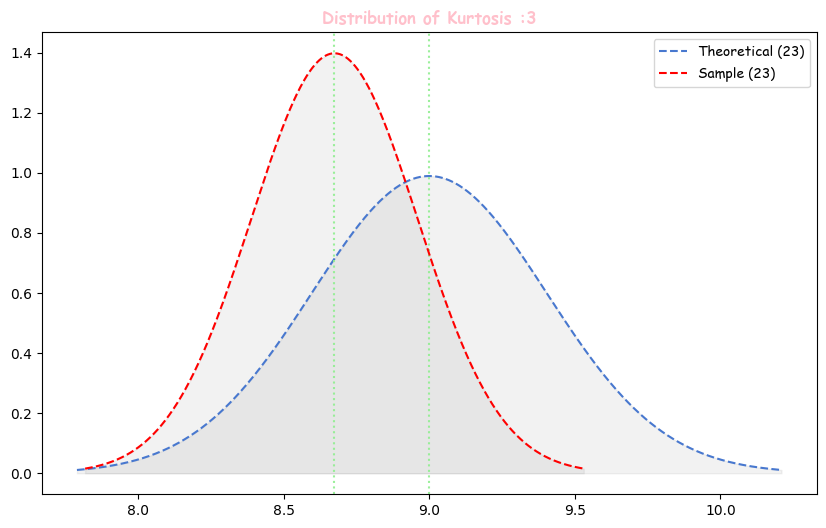

In [98]:
plt.style.use('seaborn-v0_8-muted')
random.seed(42)
np.random.seed(42)

def binom(moments, n, val = -1):
    #Binomial theorem
    sum = 0
    for i in range(n + 1):
        sum += math.comb(n, i) * moments[n - i] * ((moments[1] * val) ** i)
        
    return sum

def estimate_central(moments, sz=None):
    mu_2, mu_4, mu_6, mu_8 = binom(moments, 2), binom(moments, 4), binom(moments, 6), binom(moments, 8)

    cov_mat = np.zeros((2, 2))

    #Var(mu2)
    cov_mat[0][0] = mu_4 - mu_2**2
    #Cov(mu2, mu4)
    cov_mat[0][1] = mu_6 - mu_2 * mu_4
    cov_mat[1][0] = cov_mat[0][1]
    #Var(mu4)
    cov_mat[1][1] = mu_8 - mu_4**2

    #Gradient
    J = np.array([-2 * mu_4 / (mu_2 ** 3), 1 / (mu_2 ** 2) ])
    d_var = J @ cov_mat @ (J.T)

    if sz is not None:
        d_var /= sz

    d_mu = mu_4 / (mu_2 ** 2)
    d_sigma = np.sqrt(d_var)
    print("loc, scale:", d_mu, d_sigma)

    x_values = np.linspace(d_mu - 3 * d_sigma, d_mu + 3 * d_sigma, 2000)
    t_values = sc.stats.norm.pdf(x_values, loc=d_mu, scale=d_sigma )

    return x_values, t_values, d_mu

def plot_exp(d_lambda : float, sz):
    #Moments up to 8
    cur, fact = 1, []
    for i in range(1, 9):
        fact.append( cur := cur * i)
    moments = [fact[i - 1] / (d_lambda ** i) for i in range(1, 9)]
    moments.insert(0, 1)
    plt.figure(figsize=(10, 6), dpi=100)


    x_values, t_values, d_mu = estimate_central(moments, sz=sz)

    plt.plot(x_values, t_values, label=f"Theoretical ({d_lambda})", linestyle='--')
    plt.fill_between(x_values, t_values, color='grey', alpha=0.1)
    plt.axvline(d_mu, color='lightgreen', linestyle=':', alpha=0.9)

    sample = np.random.exponential(scale=1/d_lambda, size=sz)
    moments = [1]
    for i in range(1, 9):
        res = (sample ** i).sum() / sz
        moments.append(res)
    
    x_values, t_values, d_mu = estimate_central(moments, sz=sz)

    plt.plot(x_values, t_values, label=f"Sample ({d_lambda})", linestyle='--', color='red')
    plt.fill_between(x_values, t_values, color='grey', alpha=0.1)
    plt.axvline(d_mu, color='lightgreen', linestyle=':', alpha=0.9)

    plt.title("Distribution of Kurtosis :3", fontweight='heavy', color='pink', family='cursive')
    plt.legend(prop={'family': 'cursive'})


plot_exp(23, 50000)

"""
interact(plot_exp, 
         d_lambda=(23, 23, 1), # (min, max, step)
         sz=(3000, 5000, 100))      
plot_exp(d_lambda=23, sz=2000)
"""

Kurtosis measures similarity of given distribution to normal. It is very unstable metric on distributions with heavy tails. Because we are using 8-th central moment to estimate parameters, convergence rate is very low. 

Let's try to find distribution for IQR instead of Kurtosis

$$ \widehat{q}_\alpha\sim N(q_\alpha, \frac{\alpha(1-\alpha)}{n\cdot f(q_\alpha)^2}) $$

In multivariate case, we will have a vector of quantiles as mean and variance matrix(V) where 

$$ V_{i, j} = \frac{p_{\widehat{i}} (1- p_{\widehat{j}})}{n} \cdot \frac{1}{f(q_{p_i})f(q_{p_j})} \: where \: f(q_{p_j}) \: is \: pdf \: at \: q_{p_j},\: p_{\widehat{i}}=min(p_i, p_j),\: p_{\widehat{j}}=max(p_i, p_j) $$

From previous notebook:

$$ Theoretical\:mean\:and\:variance\:for\:exponential\:distribution $$
$$ f_X(x) = \lambda e^{-\lambda x} \: (for\:x>0) \: and \: F_X(x) = (1-e^{-\lambda x}) $$
$$ Quantile: \:1-e^{-\lambda x_p}=p \: \to \:e^{-\lambda x_p}=1-p \: \to \:-\lambda x_p=ln(1-p) $$
$$ x_p=\frac{-ln(1-p)}{\lambda} $$
$$ Variance: \: Var(\widehat{x}_p)=\frac{p(1-p)}{n\cdot f(x_p)^2} $$
$$ f(x_p)=\lambda e^{-\lambda\frac{-ln(1-p)}{\lambda}} = \lambda(1-p) $$
$$ Var(\widehat{x}_p)=\frac{p}{n\lambda^2(1-p)} $$

But this time we need to find pdf for different values p in denominator

C:\Users\Alim\AppData\Local\Temp\ipykernel_13780\3276608571.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cov_mat[i][j] = min(q[i], q[j]) * (1 - max(q[i], q[j])) / (sz * density(q_est[i]) * density(q_est[j]))


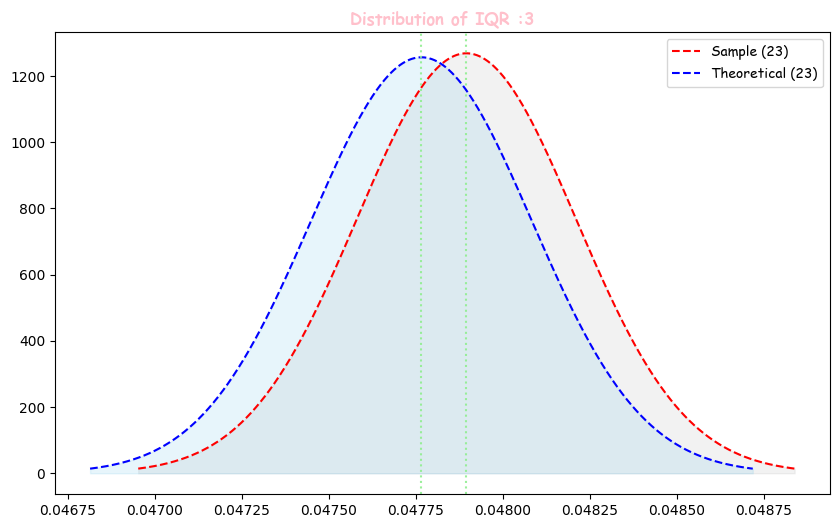

In [99]:
def estimate_iqr(d_lambda : float, sz = None):
    sample = np.random.exponential(scale=1/d_lambda, size=sz)
    sample = sorted(sample)

    #Sample distribution
    plt.figure(figsize=(10, 6), dpi=100)
    density = sc.stats.gaussian_kde(sample)
    q = [0.25, 0.75]
    q_est = np.percentile(sample, [25, 75])

    cov_mat = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            cov_mat[i][j] = min(q[i], q[j]) * (1 - max(q[i], q[j])) / (sz * density(q_est[i]) * density(q_est[j]))

    mu_est = q_est[1] - q_est[0]
    J = np.array([-1, 1])
    var_est = J @ cov_mat @ J.T

    sigma_est = np.sqrt(var_est)
    x_values = np.linspace(mu_est - 3 * sigma_est, mu_est + 3 * sigma_est, 5000)
    est_values = sc.stats.norm.pdf(x_values, loc=mu_est, scale=sigma_est)
    
    plt.plot(x_values, est_values, label=f"Sample ({d_lambda})", linestyle='--', color='red')
    plt.fill_between(x_values, est_values, color='grey', alpha=0.1)
    plt.axvline(mu_est, color='lightgreen', linestyle=':', alpha=0.9)

    #Theoretical distribution
    val = lambda x : -np.log(1 - x) / d_lambda
    q_t = np.array([val(q[0]), val(q[1])])

    cov_mat = np.zeros((2, 2))
    for i in range(0, 2):
        for j in range(0, 2):
            p = min(q[i], q[j])
            cov_mat[i][j] = p / (sz * d_lambda**2 * (1 - p))
    
    mu_t = q_t[1] - q_t[0]
    var_t = J @ cov_mat @ J.T
    sigma_t = np.sqrt(var_t)

    x_values = np.linspace(mu_t - 3 * sigma_t, mu_t + 3 * sigma_t, 5000)
    t_values = sc.stats.norm.pdf(x_values, loc=mu_t, scale=sigma_t)
    
    plt.plot(x_values, t_values, label=f"Theoretical ({d_lambda})", linestyle='--', color='blue')
    plt.fill_between(x_values, t_values, color='skyblue', alpha=0.2)
    plt.axvline(mu_t, color='lightgreen', linestyle=':', alpha=0.9)

    plt.title("Distribution of IQR :3", fontweight='heavy', color='pink', family='cursive')
    plt.legend(prop={'family': 'cursive'})



estimate_iqr(23, 50000)

IQR is more stable than Kurtosis because it doesn't care about tails, while it is difficult to get enough extreme values to estimate the true parameter for Kurtosis. Thus convergence rate for IQR is significantly higher.